In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data
from time import perf_counter
import pandas
import pickle
import os

seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_LF = "../DATA/reaction_diffusion_LF_28_d1.mat"
(reaction_LF_test, U_LF_test) = import_data(file_path_LF)
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

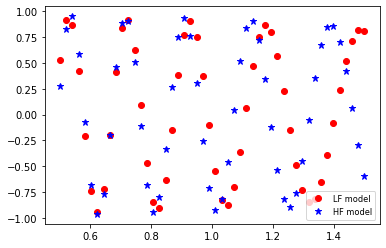

In [3]:
plt.figure()
plt.plot(reaction_LF_test, U_LF_test[
    :,
     - 1,
    12,12
], "ro", linewidth=1.5, label="LF model")
plt.plot(
    reaction_HF_test,
    U_HF_test[
    :,
     - 1,
    44,44
],
    "b*",
    markersize=7,
    label="HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

In [4]:
########################     NORMALIZATION  #########################
# Input
reaction_max = np.max(reaction_LF_test)
reaction_min = np.min(reaction_LF_test)

# reaction_test_norm = (reaction_test - reaction_min) / (reaction_max - reaction_min)
reaction_LF_test = (reaction_LF_test - reaction_min) / (
    reaction_max - reaction_min
)
reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)

In [5]:
#########################     TRAIN SET      ##########################
NepoLF = 1000  # number of epochs for first NN: NN_LF
NepoHF = 3000  # number of epochs for second NN: NN_HF

permutation = np.random.permutation(len(reaction_LF_test))
Nlf = 20
reaction_LF = reaction_LF_test[permutation][0:Nlf]

# ADD NOISE
# noise_stddev = np.mean(reaction_LF) * 0.025
# noise = np.random.normal(0, noise_stddev, len(reaction_LF))
# reaction_LF = reaction_LF + noise

In [6]:
U_LF_test = U_LF_test[
    :,
     - 1,
    12,12
]

# TRANSFORMATION
U_t_max_test = np.max(U_LF_test)
U_t_min_test = np.min(U_LF_test)

# U_LF = (U_LF - U_t_min_train) / (U_t_max_train - U_t_min_train)
#U_LF = (U_LF - U_t_min_test) / (U_t_max_test - U_t_min_test)
U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
#U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
U_LF = U_LF_test[permutation][0:Nlf]

permutation = np.random.permutation(len(reaction_HF_test))
n_HF = 10
reaction_HF = reaction_HF_test[permutation][0:n_HF]
U_HF_test = U_HF_test[:, -1, 44,44]

# TRANSFORMATION
U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
#U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

U_HF = U_HF_test[permutation][0:n_HF]



In [7]:
##########################       FIRST NN: NN_LF     ##########################
K.clear_session()
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
}  # obtained

modelLF = getModel(bestLF_params, "LF")
histLF = modelLF.fit(
    reaction_LF, U_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
)
print("LF NN done")

ULF = modelLF.predict(reaction_LF_test)
print("\nLF Model:")

test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
print(f"Test MSE: {test_mse}")

r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
    np.square(U_LF_test - np.mean(U_LF_test))
)
print(f"R^2: {r_2}")

LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.13065386652210986
R^2: -0.10493139247594363


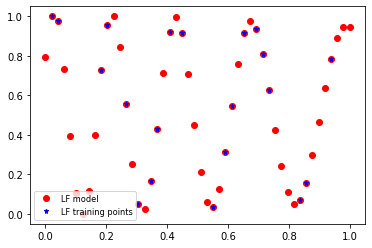

In [8]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
#plt.plot(reaction_HF_test, U_HF_test, "bo", linewidth=1.5, label="HF model")
#plt.plot(
#    reaction_HF,
#    U_HF,
#    "b*",
#    markersize=7,
#    label="HF training points",
#)
plt.plot(reaction_LF_test, U_LF_test, "ro", linewidth=1.5, label="LF model")
plt.plot(
    reaction_LF,
    U_LF,
    "b*",
    markersize=5,
    label="LF training points",
)
#plt.plot(
#    reaction_LF_test,
#    modelLF.predict(reaction_LF_test),
#    "g*",
#    label="Predicted LF model",
#)
plt.legend(prop={"size": 8.3})
plt.show()

In [9]:
print(f"\n-------  #HF data = {n_HF}  -------")
start = perf_counter()

##########################    SECOND NN: NN_HF    ##########################
reaction_test_help = modelLF.predict(reaction_LF_test)[:, 0]
reaction_test_in = np.vstack(
    (reaction_LF_test[:, 0], reaction_test_help)
).transpose()  # <- TEST INPUT for the second NN: NN_HF

reaction_train_help = modelLF.predict(reaction_HF)[:, 0]  # f_LF(mu_hf_train)
reaction_final = np.vstack(
    (reaction_HF[:, 0], reaction_train_help)
).transpose()  # <- TRAINING INPUT for the second NN: NN_HF

name = "2step"



-------  #HF data = 10  -------
1/1 [==============================] - 0s 33ms/step


In [10]:
####################    HYPERPARAMETER OPTIMIZATION    #######################
MAX_EVAL = 1

K.clear_session()
bayes_trials = Trials()
opt_list = ["Adam", "Adamax"]
kernel_list = ["uniform", "glorot_uniform"]
aux_dic = {"opt": opt_list, "kernel_init": kernel_list}
space = {
    "nodes": hp.qloguniform("nodes", np.log(4), np.log(64), 2),
    "l2weight": hp.loguniform("l2weight", np.log(0.0001), np.log(100)),
    "lr": hp.loguniform("lr", np.log(0.0001), np.log(0.1)),
    "kernel_init": hp.choice("kernel_init", kernel_list),
    "opt": hp.choice("opt", opt_list),
}


def objective(params):
    K.clear_session()
    CVres = kCrossVal(n_HF, NepoHF, reaction_final, U_HF, params, name)

    # mse, r_squared = calculate_metrics(Nhf, NepoHF, mu_final, U_hf_train, params, name)   # ADDED

    # return {'loss': CVres, 'mse': mse, 'r_squared': r_squared, 'params': params, 'status': STATUS_OK}
    return {"loss": CVres, "params": params, "status": STATUS_OK}


best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=MAX_EVAL,
    trials=bayes_trials,
)

transfBestparam(best_params, aux_dic)
print(best_params)


1/1 [==============================] - 0s 81ms/step 

1/1 [==============================] - 0s 34ms/step 

1/1 [==============================] - 0s 23ms/step 

1/1 [==============================] - 0s 16ms/step 

1/1 [==============================] - 0s 17ms/step 

1/1 [==============================] - 0s 26ms/step 

1/1 [==============================] - 0s 34ms/step 

1/1 [==============================] - 0s 33ms/step 

1/1 [==============================] - 0s 25ms/step 

1/1 [==============================] - 0s 42ms/step 

100%|██████████| 1/1 [02:01<00:00, 121.01s/trial, best loss: 0.11639522565141036]
{'kernel_init': 'uniform', 'l2weight': 0.5331398466751394, 'lr': 0.003594997156863324, 'nodes': 6.0, 'opt': 'Adamax'}


2/2 [==============================] - 0s 0s/step
Elapsed time:  746.894574599999

HF Model:
Test MSE: 0.15848756605894004
R^2: -0.4000818406812634
Number of HF data:  10
2/2 [==============================] - 0s 0s/step


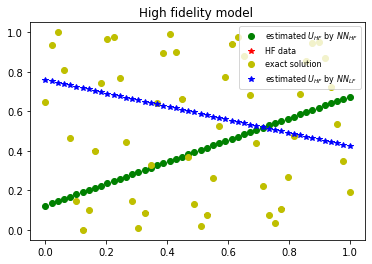

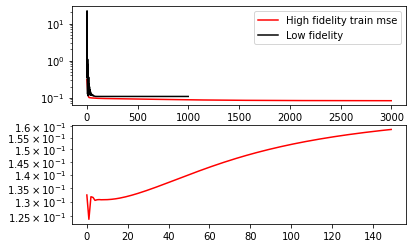

In [12]:
####################    NN_HF training and PREDICTION    #######################
finalModel = getModel(
    best_params, name
)  # final model chosen according to the best paramters
hist = finalModel.fit(
    reaction_final,
    U_HF,
    validation_data=(reaction_test_in, U_HF_test),
    epochs=NepoHF,
    batch_size=n_HF,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_test_in)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Model:")

test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
    np.square(U_HF_test - np.mean(U_HF_test))
)
print(f"R^2: {r2_HF}")

# print("Number of basis functions: ", int(Nlf_models[m]))
print("Number of HF data: ", n_HF)

####################    HF GRAPHS    #######################
plt.figure()
plt.plot(
    reaction_HF_test,
    UHF,
    "go",
    label="estimated $U_{HF}$ by $NN_{HF}$",
    linewidth=3,
)  # estimated values of u_HF by third NN
plt.plot(reaction_HF, U_HF, "ro", label="HF data")  # high fidelity data
plt.plot(
    reaction_HF_test, U_HF_test, "y*", label="exact solution"
)  # exact solution
plt.plot(
    reaction_HF_test,
    modelLF.predict(reaction_HF_test),
    "b*",
    label="estimated $U_{HF}$ by $NN_{LF}$",
    linewidth=1,
)
plt.title("High fidelity model ")
plt.legend(loc=1, prop={"size": 8})
plt.show()

####################    TRAINING INSIGHTS    #######################
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(hist.history["mse"], color="red", label="High fidelity train mse")
plt.plot(histLF.history["mse"], color="black", label="Low fidelity")
plt.legend()
plt.yscale("log")
plt.subplot(2, 1, 2)
plt.plot(hist.history["val_mse"], color="red")
plt.yscale("log")
plt.show()